In [5]:
import numpy as np 
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import linregress
import matplotlib.pyplot as plt
from uncertainties import ufloat
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

# Konstanten für Energieberechnung
hc_eV_nm = 1240  # h*c in eV*nm
h = 6.62607015e-34  # Plancksches Wirkungsquantum in Js (angepasst)
m_0 = 9.10938356e-31  # Elektronenmasse in kg (angepasst)
c= 299792458  # Lichtgeschwindigkeit in m/s (angepasst)
h_quer = h / (2 * np.pi)  # Reduziertes Plancksches Wirkungsquantum in Js (angepasst)


## Aufgabe 2: 

Peaks in L = 0.150+/-0.005:
 Anzahl der Peaks: 10
Peaks in L = 0.300+/-0.005:
 Anzahl der Peaks: 20
Peaks in L = 0.450+/-0.005:
 Anzahl der Peaks: 31
Peaks in L = 0.600+/-0.005:
 Anzahl der Peaks: 41
Peaks in L = 0.750+/-0.005:
 Anzahl der Peaks: 48
[ 1000.  2000.  3000.  4000.  5000.  6000.  7000.  8000.  9000. 10000.
 11000.]


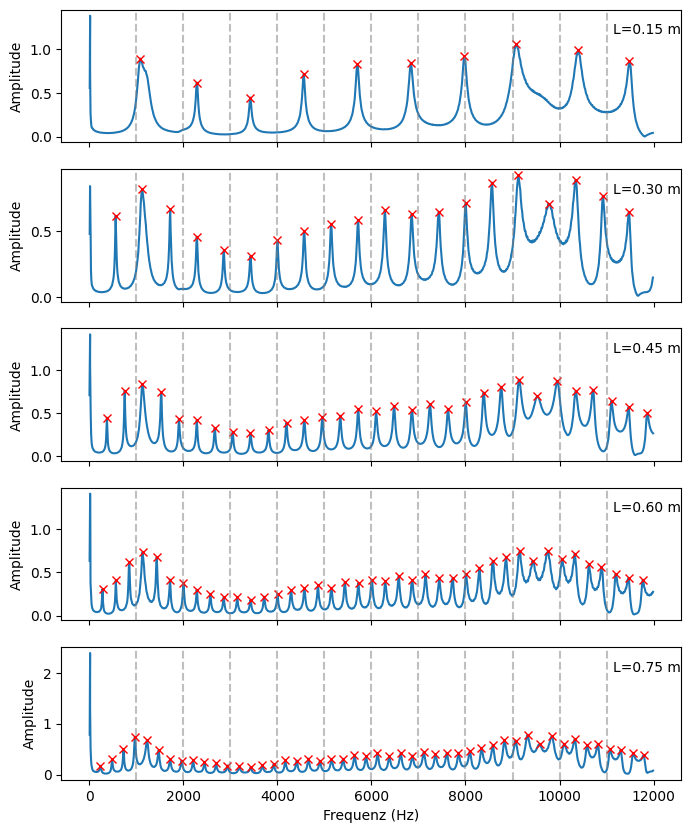

[1083.48954+/-5.0 2294.44268+/-5.0 3424.11657+/-5.0 4563.03012+/-5.0
 5704.25648+/-5.0 6843.11302+/-5.0 7974.85902+/-5.0 9083.4418+/-5.0
 10395.52402+/-5.0 11485.08651+/-5.0]


In [64]:
#Aufgabe 1 

df_ref= pd.read_csv(r"20-03-26\Ref.dat", skiprows=(0,1,2), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
#print(df_ref.head())

files= [r"20-03-26\2-15.dat", r"20-03-26\2-30.dat", r"20-03-26\2-45.dat", r"20-03-26\2-60.dat", r"20-03-26\2-75.dat" ]
längen= [ufloat(0.15, 0.005), ufloat(0.30, 0.005), ufloat(0.45, 0.005), ufloat(0.60, 0.005), ufloat(0.75, 0.005)] # in m , UNsicherheit von 0,005 m

peaks_15 = []
peaks_30 = []
peaks_45 = []
peaks_60 = []
peaks_75 = []
peaks_all= [peaks_15, peaks_30, peaks_45, peaks_60, peaks_75]

fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8,10))

def find_resonance_frequencies(files):
    for i, file in enumerate(files): 
        df = pd.read_csv(file, skiprows=(0,1,2), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
        #print(df.head())
        
        frequency= df["Frequenz"]
        #frequency= frequency.iloc[3:] # Entfernen der ersten zwei Zeilen, die möglicherweise Störsignale enthalten
        amplitude= df["Amplitude"] / df_ref["Amplitude"] # Normierung der Amplitude mit der Referenz
        #amplitude= amplitude.iloc[3:]
        
        axes[i].plot(frequency, amplitude)
        axes[i].text(0.89, 0.9, f"L={längen[i].nominal_value:.2f} m", transform=axes[i].transAxes, verticalalignment='top')
        axes[i].set_ylabel("Amplitude")
        
        peaks, properties = find_peaks(
            amplitude,
            height=0.05,        # minimale Peak-Höhe (anpassen!)
            prominence=0.02,   # wie stark der Peak herausragt
            distance=1  )
        #  mit den Parametern werden alle Peaks gefunden! 
        #TODO hier eventuell noch mit Lorentz-Fit die Peaks genauer bestimmen
        
        peaks= np.delete(peaks, 0)

        print(f"Peaks in L = {längen[i]}:")
        print(f" Anzahl der Peaks: {len(peaks)}")
        axes[i].plot(frequency[peaks], amplitude[peaks], "x", color="red")  # Markieren der Peaks

        peaks_all[i] = np.array([ufloat(frequency[peak], 5) for peak in peaks])
        
        
    axes[-1].set_xlabel("Frequenz (Hz)")

    reference_lines = np.linspace(1000,11000, 11)
    print(reference_lines)

    for ax in axes:
        for line in reference_lines:
            ax.axvline(line, linestyle="--", color="gray", alpha=0.5)  
    
    return peaks_all    

peaks_all = find_resonance_frequencies(files)
plt.show()
print(peaks_all[0])

[1083.48954+/-5.0 2294.44268+/-5.0 3424.11657+/-5.0 4563.03012+/-5.0
 5704.25648+/-5.0 6843.11302+/-5.0 7974.85902+/-5.0 9083.4418+/-5.0
 10395.52402+/-5.0 11485.08651+/-5.0]
c= 345+/-5
Fehler aus Fit: 5.116294007363732


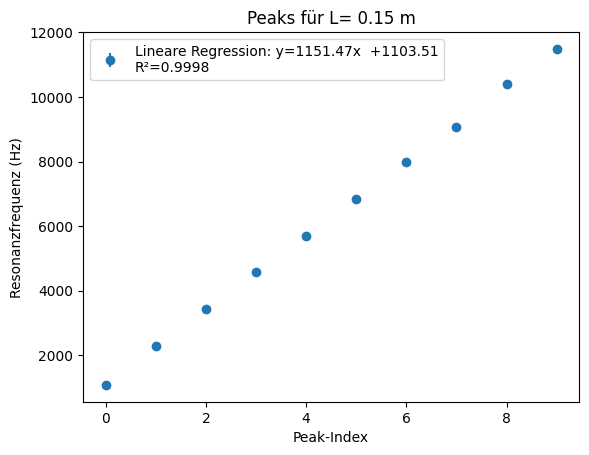

[562.79696+/-5.0 1123.35449+/-5.0 1722.79882+/-5.0 2291.95412+/-5.0
 2863.92301+/-5.0 3433.42003+/-5.0 4002.88585+/-5.0 4574.57452+/-5.0
 5144.20426+/-5.0 5713.73249+/-5.0 6283.13983+/-5.0 6854.8021+/-5.0
 7433.77144+/-5.0 8005.30581+/-5.0 8565.39457+/-5.0 9125.59598+/-5.0
 9765.36839+/-5.0 10344.26704+/-5.0 10925.11236+/-5.0 11473.58355+/-5.0]
c= 344.4+/-0.8
Fehler aus Fit: 0.76219360936656


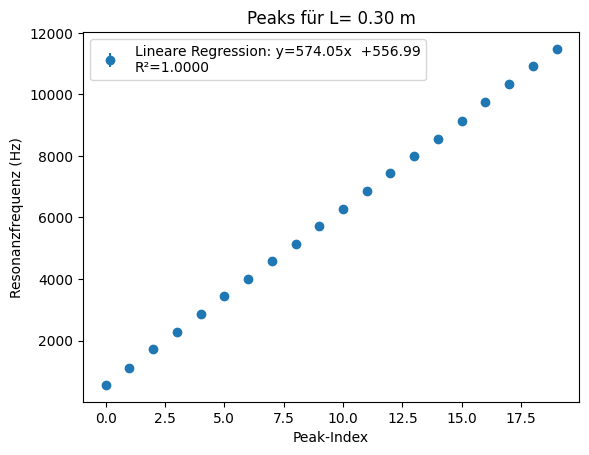

[376.71834+/-5.0 756.28148+/-5.0 1127.31937+/-5.0 1527.73109+/-5.0
 1907.27182+/-5.0 2286.93562+/-5.0 2666.78696+/-5.0 3048.55322+/-5.0
 3428.10808+/-5.0 3816.8925+/-5.0 4196.74904+/-5.0 4567.28188+/-5.0
 4958.19773+/-5.0 5337.81509+/-5.0 5717.5582+/-5.0 6097.30872+/-5.0
 6477.1556+/-5.0 6858.75915+/-5.0 7247.71057+/-5.0 7627.44184+/-5.0
 8007.18786+/-5.0 8388.88935+/-5.0 8757.21846+/-5.0 9138.78018+/-5.0
 9527.90856+/-5.0 9947.59279+/-5.0 10347.92666+/-5.0 10708.75701+/-5.0
 11107.35634+/-5.0 11467.96288+/-5.0 11868.60971+/-5.0]
c= 344.35+/-0.29
Fehler aus Fit: 0.2949952886951002


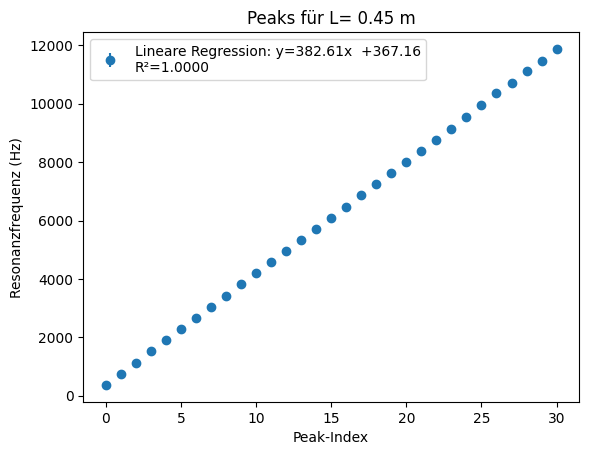

[283.91127+/-5.0 565.7455+/-5.0 853.84407+/-5.0 1135.79047+/-5.0
 1435.38962+/-5.0 1716.6619+/-5.0 2004.79971+/-5.0 2286.05785+/-5.0
 2574.3206+/-5.0 2864.6532+/-5.0 3145.98995+/-5.0 3434.11494+/-5.0
 3715.63056+/-5.0 4005.87289+/-5.0 4296.48958+/-5.0 4575.54553+/-5.0
 4865.99496+/-5.0 5145.20923+/-5.0 5435.62207+/-5.0 5725.97144+/-5.0
 6005.24927+/-5.0 6295.59422+/-5.0 6586.05907+/-5.0 6865.16058+/-5.0
 7146.35186+/-5.0 7446.09689+/-5.0 7725.19799+/-5.0 8006.30907+/-5.0
 8296.70169+/-5.0 8575.85424+/-5.0 8866.22446+/-5.0 9156.84564+/-5.0
 9426.44836+/-5.0 9756.80488+/-5.0 10056.68189+/-5.0 10326.24558+/-5.0
 10626.106+/-5.0 10886.36401+/-5.0 11195.64724+/-5.0 11467.27941+/-5.0
 11776.59387+/-5.0]
c= 344.23+/-0.16
Fehler aus Fit: 0.15771834388292877


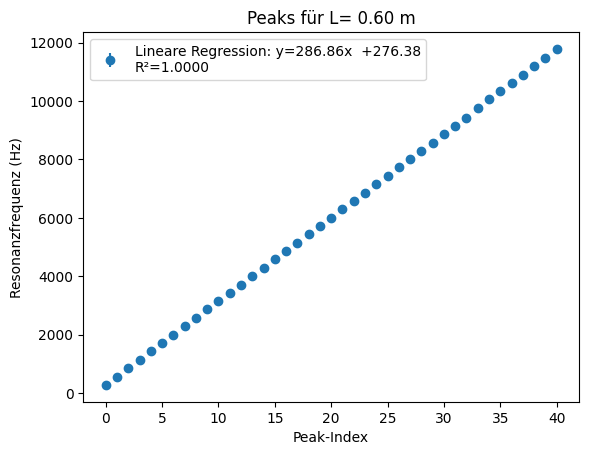

[239.44046+/-5.0 487.35818+/-5.0 728.88644+/-5.0 968.07319+/-5.0
 1228.25375+/-5.0 1478.67083+/-5.0 1718.0008+/-5.0 1968.38447+/-5.0
 2207.72136+/-5.0 2448.95685+/-5.0 2697.4851+/-5.0 2938.74709+/-5.0
 3189.40143+/-5.0 3437.81897+/-5.0 3679.13746+/-5.0 3927.58803+/-5.0
 4168.79885+/-5.0 4417.4406+/-5.0 4658.65618+/-5.0 4909.24138+/-5.0
 5148.51168+/-5.0 5399.0008+/-5.0 5638.29742+/-5.0 5888.71846+/-5.0
 6128.14299+/-5.0 6378.56342+/-5.0 6629.17845+/-5.0 6868.38806+/-5.0
 7118.9652+/-5.0 7358.27421+/-5.0 7599.44916+/-5.0 7848.11+/-5.0
 8089.17765+/-5.0 8338.02492+/-5.0 8578.91818+/-5.0 8827.95795+/-5.0
 9068.69163+/-5.0 9319.35154+/-5.0 9579.44102+/-5.0 9839.53856+/-5.0
 10098.04921+/-5.0 10329.27044+/-5.0 10589.36033+/-5.0 10819.00517+/-5.0
 11079.10178+/-5.0 11299.39459+/-5.0 11568.90088+/-5.0 11789.14647+/-5.0]
c= 368.85+/-0.11
Fehler aus Fit: 0.11418243285313769


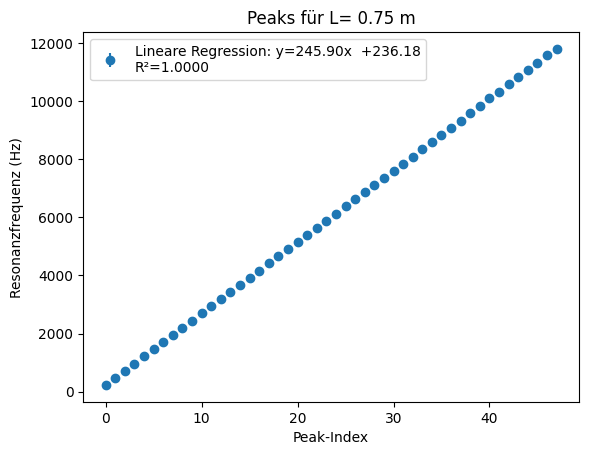

Mittlere Schallgeschwindigkeit: 349.46+/-1.04 m/s


In [78]:
c= [] # array für alle berechneten Schallgeschwindigkeiten, arrays in array für jede Länge einen

for i, peaks in enumerate(peaks_all):
    print(peaks)
    x= np.arange(len(peaks))
    y= np.array([p.nominal_value for p in peaks])
    plt.errorbar(x, y, yerr= [p.std_dev for p in peaks], fmt='o')
    plt.xlabel("Peak-Index")
    plt.ylabel("Resonanzfrequenz (Hz)")
    plt.title(f"Peaks für L= {längen[i].nominal_value:.2f} m")
    slope, intercept, r_value, p_value, std_err = linregress(x, y) #lineare Regresssion 
    
    c.append(ufloat(slope * 2 * längen[i].nominal_value, std_err) ) #Steigung * 2 * Länge (in m) = c
    
    print(f"c= {c[-1]}")
    print(f"Fehler aus Fit: {std_err}")
    plt.legend([f"Lineare Regression: y={slope:.2f}x  {intercept:+.2f}\nR²={r_value**2:.4f}"])
    plt.show()
    
c_mean= 1/len(c) * np.sum(c)
print(f"Mittlere Schallgeschwindigkeit: {c_mean:.2f} m/s")

In [62]:
# 2 theoretische Werte

c_theo= 343  # Schallgeschwindigkeit in Luft bei 20°C in m/s
f_theo= []

for i, L in enumerate(längen):
    f= []
    print(f"theoretische Referenzfrequenzen für L= {L} m:")
    print(f"Anzahl der Peaks: {len(peaks_all[i])}")
    for n in np.arange(1, len(peaks_all[i])):  #je nach Länge, unterschiedliche Anzahl von Peaks
        f_t= n* c_theo / (2 * L) 
        f.append(f_t)
        print(f"{f_t:.2f} Hz")
    f_theo.append(f)
    
print(f_theo)

theoretische Referenzfrequenzen für L= 0.150+/-0.005 m:
Anzahl der Peaks: 10
1143.33+/-38.11 Hz
2286.67+/-76.22 Hz
3430.00+/-114.33 Hz
4573.33+/-152.44 Hz
5716.67+/-190.56 Hz
6860.00+/-228.67 Hz
8003.33+/-266.78 Hz
9146.67+/-304.89 Hz
10290.00+/-343.00 Hz
theoretische Referenzfrequenzen für L= 0.300+/-0.005 m:
Anzahl der Peaks: 20
571.67+/-9.53 Hz
1143.33+/-19.06 Hz
1715.00+/-28.58 Hz
2286.67+/-38.11 Hz
2858.33+/-47.64 Hz
3430.00+/-57.17 Hz
4001.67+/-66.69 Hz
4573.33+/-76.22 Hz
5145.00+/-85.75 Hz
5716.67+/-95.28 Hz
6288.33+/-104.81 Hz
6860.00+/-114.33 Hz
7431.67+/-123.86 Hz
8003.33+/-133.39 Hz
8575.00+/-142.92 Hz
9146.67+/-152.44 Hz
9718.33+/-161.97 Hz
10290.00+/-171.50 Hz
10861.67+/-181.03 Hz
theoretische Referenzfrequenzen für L= 0.450+/-0.005 m:
Anzahl der Peaks: 31
381.11+/-4.23 Hz
762.22+/-8.47 Hz
1143.33+/-12.70 Hz
1524.44+/-16.94 Hz
1905.56+/-21.17 Hz
2286.67+/-25.41 Hz
2667.78+/-29.64 Hz
3048.89+/-33.88 Hz
3430.00+/-38.11 Hz
3811.11+/-42.35 Hz
4192.22+/-46.58 Hz
4573.33+/-50.81

In [79]:
# 2 Abweichung der experimentellen Werte von den theoretischen ReferenzFREQUENZEN

print("Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:")
for i in range(len(peaks_all)):
    print( f"für L= {längen[i].nominal_value:.2f} m:")
    for b,t in (zip(peaks_all[i], f_theo[i])): # array mit den Frequenzen für Länge i
        #print( b, t)
        pro_abw = abs(b - t) / t *100
        print( pro_abw)

Abweichung der experimentellen Werte von den theoretischen Referenzfrequenzen:
für L= 0.15 m:
5.2+/-3.2
0.3+/-3.4
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.2+/-3.3
0.4+/-3.3
0.7+/-3.3
1.0+/-3.4
für L= 0.30 m:
1.6+/-1.9
1.7+/-1.7
0.5+/-1.7
0.2+/-1.7
0.2+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.1+/-1.7
0.1+/-1.7
0.0+/-1.7
0.0+/-1.7
0.1+/-1.7
0.2+/-1.7
0.5+/-1.7
0.5+/-1.7
0.6+/-1.7
für L= 0.45 m:
1.2+/-1.7
0.8+/-1.3
1.4+/-1.2
0.2+/-1.2
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.2+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.1+/-1.1
0.1+/-1.1
0.1+/-1.1
0.0+/-1.1
0.4+/-1.1
0.6+/-1.1
0.4+/-1.1
0.5+/-1.1
0.3+/-1.1
für L= 0.60 m:
0.7+/-1.9
1.0+/-1.2
0.4+/-1.0
0.7+/-0.9
0.4+/-0.9
0.1+/-0.9
0.2+/-0.9
0.0+/-0.9
0.1+/-0.9
0.2+/-0.9
0.1+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.0+/-0.8
0.1+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0.2+/-0.8
0.1+/-0.8
0.0+/-0.8
0

C:\Users\Celina\AppData\Local\Temp\ipykernel_19004\1118313020.py:8: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  pro_abw = abs(b - t) / t *100


## Aufgabe 3:

In [ ]:
# 3 Bestimmung Resonanzfrequnzen 

